# Sales & Demand Forecasting for a UK Online Retailer

**Prepared for:** store owners, startup founders, and business managers who need a clear, no-jargon view of where sales are headed and how to plan around it.

**What this notebook does:** cleans a year of real transaction data, engineers time-based features (trend, seasonality, day-of-week effects), trains and evaluates forecasting models, and produces a 30-day forecast with business-facing charts and recommendations.

**Dataset:** [UCI Online Retail](https://archive.ics.uci.edu/ml/datasets/online+retail) — ~542,000 line-item transactions from a UK-based online retailer, December 2010 to December 2011.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from viz_style import apply_style, currency_axis, SERIES_1, SERIES_2, SERIES_2_BAND, BASELINE

apply_style()
pd.set_option("display.max_columns", 20)


## 1. Load the raw data

In [2]:
raw = pd.read_excel("../data/raw/online_retail.xlsx")
print(f"Rows: {len(raw):,}  |  Columns: {list(raw.columns)}")
print(f"Date range: {raw['InvoiceDate'].min()} to {raw['InvoiceDate'].max()}")
raw.head()


Rows: 541,909  |  Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
raw.info()
print()
raw.describe(include="all").T


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB



,count,unique,top,freq,mean,min,25%,50%,75%,max,std
InvoiceNo,541909.0,25900.0,573585.0,1114.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,-80995.0,1.0,3.0,10.0,80995.0,218.081158
InvoiceDate,541909,NaN,NaN,NaN,2011-07-04 13:34:57.156386048,2010-12-01 08:26:00,2011-03-28 11:34:00,2011-07-19 17:17:00,2011-10-19 11:27:00,2011-12-09 12:50:00,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,-11062.06,1.25,2.08,4.13,38970.0,96.759853
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,12346.0,13953.0,15152.0,16791.0,18287.0,1713.600303
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Clean the transaction data

Raw retail transaction exports always need a pass of cleaning before they can be trusted:

- **Cancellations** — `InvoiceNo` values starting with `"C"` are returns/cancellations, not sales.
- **Bad quantities/prices** — a handful of rows have `Quantity <= 0` or `UnitPrice <= 0` (adjustments, data-entry errors); these aren't real sales either.
- **Missing product descriptions** — a small number of rows have no `Description`, usually bookkeeping adjustments rather than product sales.

`CustomerID` is missing for many rows, but that's irrelevant here — we're forecasting total revenue, not building a customer-level model, so we keep those rows.


In [4]:
n_before = len(raw)

df = raw.copy()
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
df = df[df["Description"].notna()]
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

n_after = len(df)
pct_dropped = (n_before - n_after) / n_before * 100
print(f"Rows before cleaning: {n_before:,}")
print(f"Rows after cleaning:  {n_after:,}")
print(f"Dropped: {n_before - n_after:,} rows ({pct_dropped:.1f}%)")

assert (df["Revenue"] < 0).sum() == 0, "Negative revenue remains after cleaning"
assert df["Description"].isna().sum() == 0, "Missing descriptions remain after cleaning"
print("Checks passed: no negative revenue, no missing descriptions.")


Rows before cleaning: 541,909
Rows after cleaning:  530,104
Dropped: 11,805 rows (2.2%)
Checks passed: no negative revenue, no missing descriptions.


## 3. Build the daily revenue series

The task is to forecast **UK daily revenue** (about 91% of all transactions), since a single clear market tells a cleaner story than blending currencies and geographies. We also pull two descriptive-only summaries (top countries, top products) to support the business narrative later — those are not forecast individually.

The transaction data is at the line-item level, so we aggregate to one revenue total per calendar day, then fill in any day with zero recorded transactions as `0` (rather than silently dropping it) so the series has a regular daily frequency — required for lag/rolling features later. The final month (December 2011) is cut off mid-month in the source data, so we truncate the series at the last **complete** month to avoid the model mistaking a data cutoff for a demand collapse.


In [5]:
uk = df[df["Country"] == "United Kingdom"].copy()
uk["Date"] = uk["InvoiceDate"].dt.normalize()

daily = uk.groupby("Date")["Revenue"].sum()

full_range = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily = daily.reindex(full_range, fill_value=0.0)
daily.index.name = "Date"

# Truncate the trailing partial month (Dec 2011 only has data through the 9th).
last_full_month_end = (daily.index.max().replace(day=1) - pd.Timedelta(days=1))
daily = daily.loc[:last_full_month_end]

assert len(daily) == (daily.index.max() - daily.index.min()).days + 1, "Gaps in the daily date index"
assert daily.isna().sum() == 0, "Unexpected NaNs in daily revenue series"

print(f"Daily series: {daily.index.min().date()} to {daily.index.max().date()}  ({len(daily)} days)")
print(f"Total revenue: £{daily.sum():,.0f}  |  Average day: £{daily.mean():,.0f}")

daily_revenue = daily.rename("Revenue").reset_index()
daily_revenue.to_csv("../data/processed/daily_revenue.csv", index=False)
daily_revenue.tail()


Daily series: 2010-12-01 to 2011-11-30  (365 days)
Total revenue: £8,432,600  |  Average day: £23,103


,Date,Revenue
360,2011-11-26,0.00
361,2011-11-27,19781.17
362,2011-11-28,52649.14
363,2011-11-29,65304.01
364,2011-11-30,50546.43


In [6]:
top_countries = (
    df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(5)
)

# Exclude non-product line items (postage, manual adjustments, bank charges, etc.)
# so "top products" reflects genuine stocked items, not fees or shipping.
NON_PRODUCT_CODES = {"POST", "D", "C2", "DOT", "M", "BANK CHARGES", "S", "AMAZONFEE", "CRUK"}
uk_products_only = uk[~uk["StockCode"].astype(str).str.upper().isin(NON_PRODUCT_CODES)]
top_products_uk = (
    uk_products_only.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
)

print("Top 5 countries by revenue:")
print(top_countries.apply(lambda x: f"£{x:,.0f}"))
print()
print("Top 10 products by revenue (UK):")
print(top_products_uk.apply(lambda x: f"£{x:,.0f}"))


Top 5 countries by revenue:
Country
United Kingdom    £9,025,222
Netherlands         £285,446
EIRE                £283,454
Germany             £228,867
France              £209,715
Name: Revenue, dtype: object

Top 10 products by revenue (UK):
Description
PAPER CRAFT , LITTLE BIRDIE           £168,470
REGENCY CAKESTAND 3 TIER              £142,273
WHITE HANGING HEART T-LIGHT HOLDER    £100,498
PARTY BUNTING                          £93,659
JUMBO BAG RED RETROSPOT                £86,471
MEDIUM CERAMIC TOP STORAGE JAR         £80,576
PAPER CHAIN KIT 50'S CHRISTMAS         £62,743
ASSORTED COLOUR BIRD ORNAMENT          £54,757
CHILLI LIGHTS                          £53,337
PICNIC BASKET WICKER 60 PIECES         £39,620
Name: Revenue, dtype: object


## 4. Time-based feature engineering

We don't have `statsmodels`/`prophet` available, so trend and seasonality are engineered as explicit columns a plain regression model can use directly:

- **Calendar features** — day of week, weekend flag, day of month, month, quarter, week of year, month start/end flags.
- **Cyclical encodings** — day-of-week and month expressed as `sin`/`cos` pairs, so the model sees "Sunday is next to Monday" and "December is next to January" instead of treating them as unrelated numbers.
- **Trend index** — a simple day-count since the series start, so a linear model can pick up on overall growth or decline.
- **Lag features** — revenue 1, 7, and 14 days ago (yesterday, same weekday last week, same weekday two weeks ago).
- **Rolling statistics** — 7- and 28-day rolling mean/std, computed on *shifted* data so today's row never sees today's own revenue (that would be leakage).
- **Holiday flag** — UK bank holidays and Christmas/Boxing Day/New Year, the single strongest seasonal driver in this dataset.

The first 28 rows don't have a full 28-day rolling window yet, so they're dropped before modeling.


In [7]:
import holidays as holidays_pkg

feat = daily_revenue.set_index("Date").copy()
feat.index = pd.DatetimeIndex(feat.index)

# Calendar features
feat["day_of_week"] = feat.index.dayofweek
feat["is_weekend"] = (feat["day_of_week"] >= 5).astype(int)
feat["day_of_month"] = feat.index.day
feat["month"] = feat.index.month
feat["quarter"] = feat.index.quarter
feat["week_of_year"] = feat.index.isocalendar().week.astype(int)
feat["is_month_start"] = feat.index.is_month_start.astype(int)
feat["is_month_end"] = feat.index.is_month_end.astype(int)

# Cyclical encodings
feat["dow_sin"] = np.sin(2 * np.pi * feat["day_of_week"] / 7)
feat["dow_cos"] = np.cos(2 * np.pi * feat["day_of_week"] / 7)
feat["month_sin"] = np.sin(2 * np.pi * feat["month"] / 12)
feat["month_cos"] = np.cos(2 * np.pi * feat["month"] / 12)

# Trend
feat["trend_idx"] = np.arange(len(feat))

# Lag features (past actuals only)
feat["lag_1"] = feat["Revenue"].shift(1)
feat["lag_7"] = feat["Revenue"].shift(7)
feat["lag_14"] = feat["Revenue"].shift(14)

# Rolling stats computed on shifted data, so today's row never sees today's revenue
feat["rolling_mean_7"] = feat["Revenue"].shift(1).rolling(7).mean()
feat["rolling_mean_28"] = feat["Revenue"].shift(1).rolling(28).mean()
feat["rolling_std_7"] = feat["Revenue"].shift(1).rolling(7).std()

# Holiday flag (UK)
uk_holidays = holidays_pkg.UK(years=[2010, 2011])
feat["is_holiday"] = feat.index.to_series().apply(lambda d: 1 if d in uk_holidays else 0)

n_before_dropna = len(feat)
feat = feat.dropna()
print(f"Dropped {n_before_dropna - len(feat)} warm-up rows with incomplete rolling/lag windows.")
print(f"Feature table: {feat.shape[0]} rows x {feat.shape[1]} columns")
feat.head()


Dropped 28 warm-up rows with incomplete rolling/lag windows.
Feature table: 337 rows x 21 columns


,Revenue,day_of_week,is_weekend,day_of_month,month,quarter,week_of_year,is_month_start,is_month_end,dow_sin,...,month_sin,month_cos,trend_idx,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_28,rolling_std_7,is_holiday
Date,,,,,,,,,,,,,,,,,,,,,
2010-12-29,0.0,2,0,29,12,4,52,0,0,0.974928,...,-2.449294e-16,1.000000,28,0.0,5488.85,30248.73,2269.080000,26723.892143,4125.861566,0
2010-12-30,0.0,3,0,30,12,4,52,0,0,0.433884,...,-2.449294e-16,1.000000,29,0.0,10394.71,47748.09,1484.958571,24766.103571,3928.831087,0
2010-12-31,0.0,4,0,31,12,4,52,0,1,-0.433884,...,-2.449294e-16,1.000000,30,0.0,0.00,34357.25,0.000000,23067.156071,0.000000,0
2011-01-01,0.0,5,1,1,1,1,52,1,0,-0.974928,...,5.000000e-01,0.866025,31,0.0,0.00,0.00,0.000000,21591.845714,0.000000,1
2011-01-02,0.0,6,1,2,1,1,52,0,0,-0.781831,...,5.000000e-01,0.866025,32,0.0,0.00,6653.94,0.000000,21591.845714,0.000000,0


## 5. Train / test split

The split must respect time — we never let the model train on the future to predict the past. We hold out the **last 56 days (8 weeks)** as a realistic test of "predict sales the model has never seen," and use a 5-fold `TimeSeriesSplit` on the training portion as a stability check (does performance hold up across different historical windows, not just one lucky split).


In [8]:
from sklearn.model_selection import TimeSeriesSplit

FEATURE_COLS = [
    "day_of_week", "is_weekend", "day_of_month", "month", "quarter", "week_of_year",
    "is_month_start", "is_month_end", "dow_sin", "dow_cos", "month_sin", "month_cos",
    "trend_idx", "lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_mean_28",
    "rolling_std_7", "is_holiday",
]
TARGET_COL = "Revenue"

HOLDOUT_DAYS = 56
train_df = feat.iloc[:-HOLDOUT_DAYS]
test_df = feat.iloc[-HOLDOUT_DAYS:]

X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]

print(f"Train: {train_df.index.min().date()} to {train_df.index.max().date()}  ({len(train_df)} days)")
print(f"Test:  {test_df.index.min().date()} to {test_df.index.max().date()}  ({len(test_df)} days)")
assert train_df.index.max() < test_df.index.min(), "Train/test overlap detected"

tscv = TimeSeriesSplit(n_splits=5)
for i, (tr_idx, val_idx) in enumerate(tscv.split(X_train)):
    tr_range = (train_df.index[tr_idx.min()].date(), train_df.index[tr_idx.max()].date())
    val_range = (train_df.index[val_idx.min()].date(), train_df.index[val_idx.max()].date())
    print(f"Fold {i+1}: train {tr_range[0]}..{tr_range[1]}  ->  validate {val_range[0]}..{val_range[1]}")


Train: 2010-12-29 to 2011-10-05  (281 days)
Test:  2011-10-06 to 2011-11-30  (56 days)
Fold 1: train 2010-12-29..2011-02-17  ->  validate 2011-02-18..2011-04-04
Fold 2: train 2010-12-29..2011-04-04  ->  validate 2011-04-05..2011-05-20
Fold 3: train 2010-12-29..2011-05-20  ->  validate 2011-05-21..2011-07-05
Fold 4: train 2010-12-29..2011-07-05  ->  validate 2011-07-06..2011-08-20
Fold 5: train 2010-12-29..2011-08-20  ->  validate 2011-08-21..2011-10-05


## 6. Train forecasting models

Three models, in increasing sophistication:

1. **Naive baseline** ("predict same weekday last week") — not really a model, just the `lag_7` feature used directly as the prediction. Any real model that can't beat this isn't earning its complexity.
2. **Linear Regression** — interpretable; its coefficients on `trend_idx`, `month_sin/cos`, `dow_sin/cos` translate directly into plain-English statements later ("weekends run below average," "Q4 trend is rising").
3. **Random Forest** — captures nonlinear day-of-week x month interactions a linear model misses.


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# 1. Naive baseline: same weekday, one week ago
naive_pred = X_test["lag_7"].values

# 2. Linear Regression
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
lin_pred = lin_model.predict(X_test)

# 3. Random Forest
rf_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("Models trained. Top features driving the Random Forest forecast:")
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
importances.head(8).apply(lambda x: f"{x:.1%}")


Models trained. Top features driving the Random Forest forecast:


lag_7              25.6%
trend_idx          14.1%
dow_sin            11.0%
day_of_week         9.2%
rolling_mean_28     7.2%
is_weekend          6.5%
rolling_mean_7      5.9%
lag_1               4.8%
dtype: object

## 7. Evaluate against the naive baseline

We score each model on the 56-day holdout using three metrics:

- **MAE** — average £ error per day (easiest to explain to a business owner)
- **RMSE** — same units, but penalizes big misses (spike days) more heavily
- **MAPE** — error as a % of actual revenue (computed only over days with `Revenue > 0`, to avoid dividing by zero on no-sales days)

The bar to clear is simple: **a real model must beat the naive "same day last week" guess.**


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results = []
for name, preds in [("Naive (lag-7)", naive_pred), ("Linear Regression", lin_pred), ("Random Forest", rf_pred)]:
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape_val = mape(y_test.values, preds)
    results.append({"Model": name, "MAE (£)": mae, "RMSE (£)": rmse, "MAPE (%)": mape_val})

results_df = pd.DataFrame(results).set_index("Model").round(1)
best_model_name = results_df["MAE (£)"].idxmin()
avg_daily_revenue = daily_revenue["Revenue"].mean()  # full-year average, for growth context later
recent_avg_revenue = y_test.mean()  # average revenue over the same window as the holdout metrics
best_mae = results_df.loc[best_model_name, "MAE (£)"]
best_mae_pct = best_mae / recent_avg_revenue * 100

print(results_df)
print()
beats_naive = best_mae < results_df.loc["Naive (lag-7)", "MAE (£)"]
print(f"Best model: {best_model_name}  (beats naive baseline: {beats_naive})")
print(
    f"On a typical day in the holdout period, the {best_model_name} forecast is off by about "
    f"£{best_mae:,.0f} — roughly {best_mae_pct:.1f}% of that period's average daily revenue "
    f"(£{recent_avg_revenue:,.0f}/day). The business grew substantially over the year "
    f"(full-year average was £{avg_daily_revenue:,.0f}/day), so recent revenue is the fairer "
    f"yardstick for judging forecast accuracy."
)


                   MAE (£)  RMSE (£)  MAPE (%)
Model                                         
Naive (lag-7)      11146.9   16276.2      32.6
Linear Regression  10480.3   14303.0      24.2
Random Forest      10695.4   15701.8      32.2

Best model: Linear Regression  (beats naive baseline: True)
On a typical day in the holdout period, the Linear Regression forecast is off by about £10,480 — roughly 28.1% of that period's average daily revenue (£37,334/day). The business grew substantially over the year (full-year average was £23,103/day), so recent revenue is the fairer yardstick for judging forecast accuracy.


## 8. Forecast the next 30 days

To forecast beyond the observed history, we retrain the winning model (Linear Regression) on **all** available data — there's no reason to hold out the last 56 days once we're done evaluating — and then forecast forward day by day. Each step's lag/rolling features come from real history plus whatever we've already predicted for the days in between, since actual future values don't exist yet. This is why forecast uncertainty grows the further out we look: small errors early in the horizon feed into later predictions.


In [11]:
from forecasting import forecast_future

final_model = LinearRegression()
final_model.fit(feat[FEATURE_COLS], feat[TARGET_COL])

history_series = daily_revenue.set_index("Date")["Revenue"]
series_start = daily_revenue["Date"].min()
future_holidays = holidays_pkg.UK(years=[2010, 2011, 2012])

FORECAST_HORIZON = 30
forecast_df = forecast_future(
    model=final_model,
    history_revenue=history_series,
    feature_cols=FEATURE_COLS,
    series_start=series_start,
    horizon_days=FORECAST_HORIZON,
    holidays_calendar=future_holidays,
)

holdout_rmse = results_df.loc["Linear Regression", "RMSE (£)"]
print(f"Forecasting {FORECAST_HORIZON} days: {forecast_df.index.min().date()} to {forecast_df.index.max().date()}")
print(f"Forecast average: £{forecast_df['Forecast'].mean():,.0f}/day  |  historical average: £{avg_daily_revenue:,.0f}/day")
assert (forecast_df["Forecast"] >= 0).all(), "Forecast produced negative revenue"
forecast_df.head()


Forecasting 30 days: 2011-12-01 to 2011-12-30
Forecast average: £45,335/day  |  historical average: £23,103/day


,Forecast
Date,
2011-12-01,38286.954816
2011-12-02,48053.579542
2011-12-03,14819.225677
2011-12-04,31989.953687
2011-12-05,52814.239175


## 9. Visualizations

### Chart 1 — Historical trend

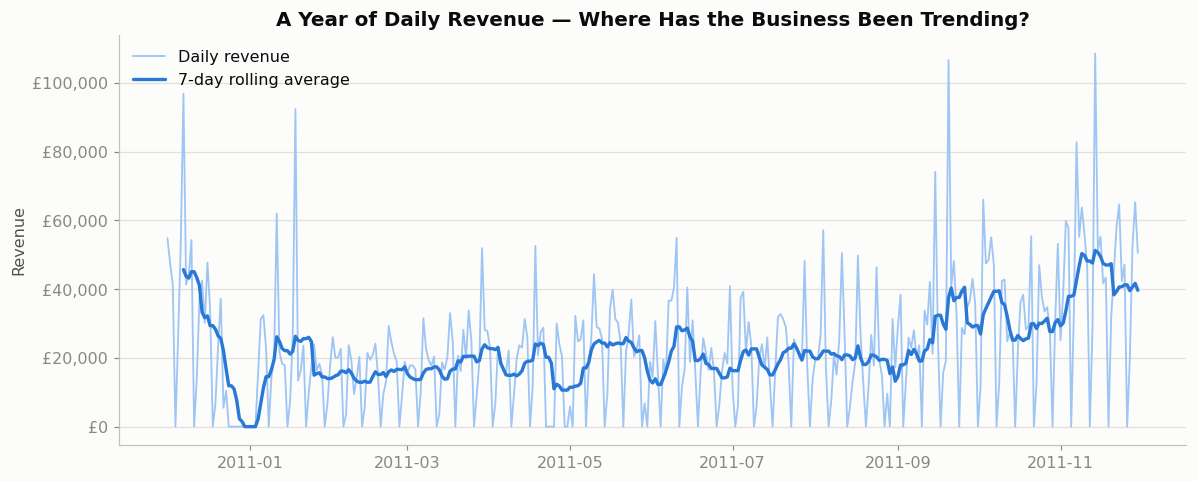

In [12]:
fig, ax = plt.subplots(figsize=(11, 4.5))
hist = daily_revenue.set_index("Date")["Revenue"]
ax.plot(hist.index, hist.values, color=SERIES_2_BAND, linewidth=1.2, label="Daily revenue")
ax.plot(hist.index, hist.rolling(7).mean(), color=SERIES_1, linewidth=2.2, label="7-day rolling average")
ax.set_title("A Year of Daily Revenue — Where Has the Business Been Trending?")
ax.set_ylabel("Revenue")
currency_axis(ax)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("../outputs/figures/01_historical_trend.png")
plt.show()


### Chart 2 — Monthly seasonality

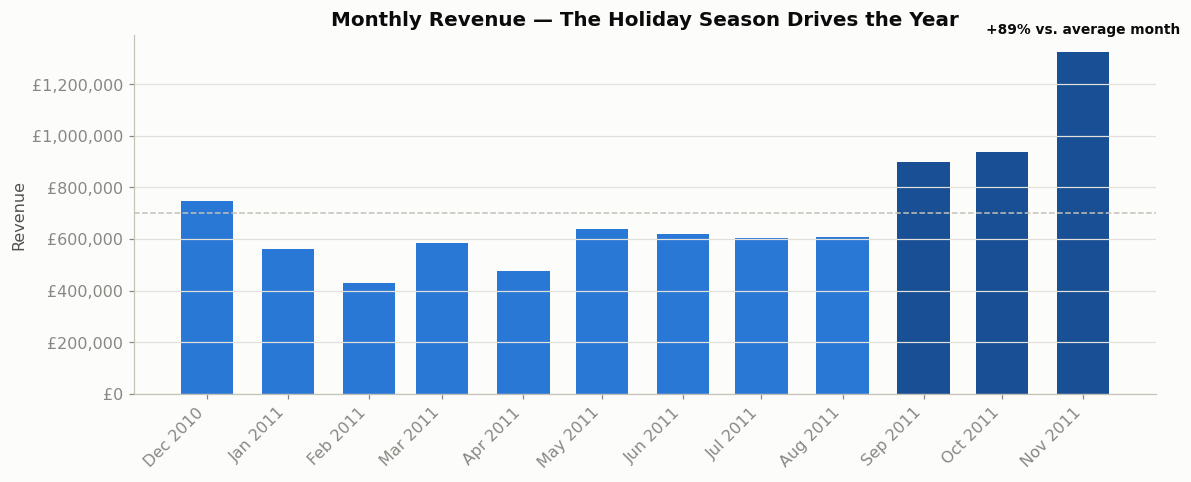

In [13]:
monthly = daily_revenue.set_index("Date")["Revenue"].resample("MS").sum()
avg_month = monthly.mean()
colors = [SERIES_1 if v <= avg_month * 1.15 else "#184f95" for v in monthly.values]

fig, ax = plt.subplots(figsize=(11, 4.5))
bars = ax.bar(monthly.index, monthly.values, width=20, color=colors)
ax.axhline(avg_month, color=BASELINE, linewidth=1, linestyle="--")
peak_month = monthly.idxmax()
peak_pct = (monthly.max() / avg_month - 1) * 100
ax.annotate(
    f"+{peak_pct:.0f}% vs. average month",
    xy=(peak_month, monthly.max()),
    xytext=(0, 12),
    textcoords="offset points",
    ha="center",
    fontsize=9,
    color="#0b0b0b",
    fontweight="bold",
)
ax.set_title("Monthly Revenue — The Holiday Season Drives the Year")
ax.set_ylabel("Revenue")
currency_axis(ax)
ax.set_xticks(monthly.index)
ax.set_xticklabels(monthly.index.strftime("%b %Y"), rotation=45, ha="right")
fig.tight_layout()
fig.savefig("../outputs/figures/02_monthly_seasonality.png")
plt.show()


### Chart 3 — Day-of-week pattern

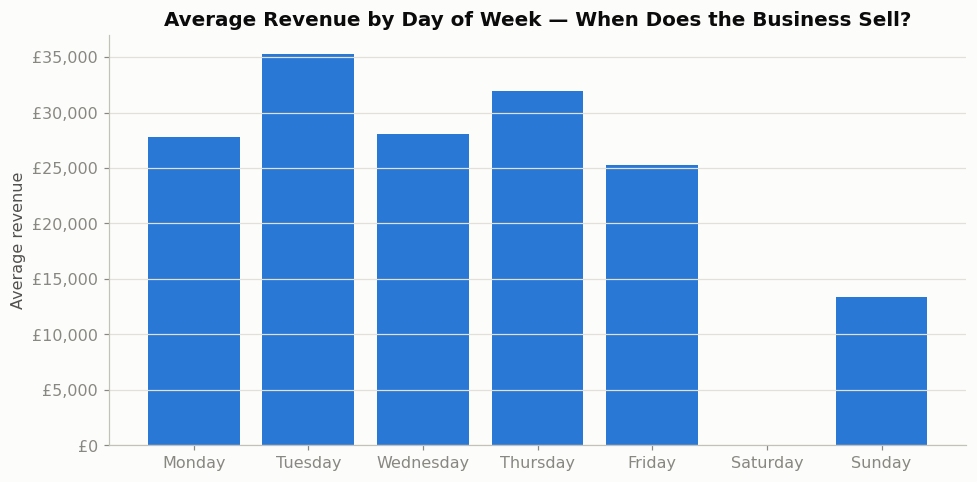

In [14]:
dow_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_avg = daily_revenue.assign(dow=daily_revenue["Date"].dt.dayofweek).groupby("dow")["Revenue"].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(dow_labels, dow_avg.values, color=SERIES_1)
ax.set_title("Average Revenue by Day of Week — When Does the Business Sell?")
ax.set_ylabel("Average revenue")
currency_axis(ax)
fig.tight_layout()
fig.savefig("../outputs/figures/03_day_of_week.png")
plt.show()


### Chart 4 — Actual vs. predicted (holdout)

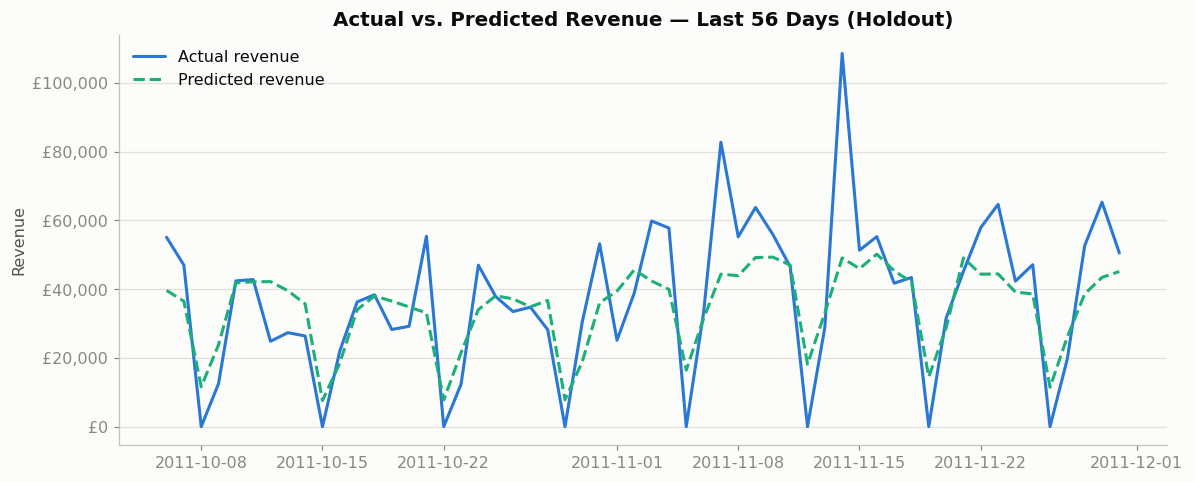

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(test_df.index, y_test.values, color=SERIES_1, linewidth=2, label="Actual revenue")
ax.plot(test_df.index, lin_pred, color=SERIES_2, linewidth=2, linestyle="--", label="Predicted revenue")
ax.set_title("Actual vs. Predicted Revenue — Last 56 Days (Holdout)")
ax.set_ylabel("Revenue")
currency_axis(ax)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("../outputs/figures/04_actual_vs_predicted.png")
plt.show()


### Chart 5 — Residual analysis

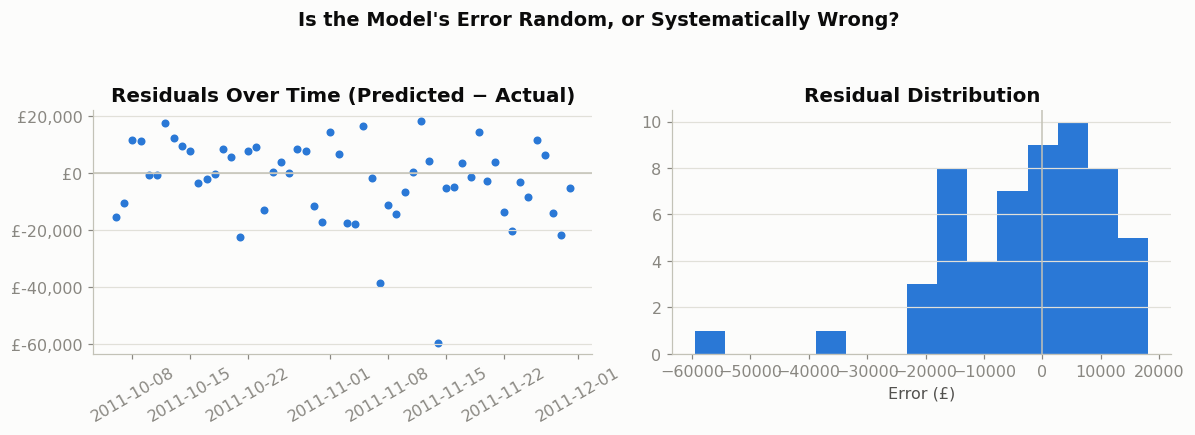

In [16]:
residuals = lin_pred - y_test.values

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].axhline(0, color=BASELINE, linewidth=1)
axes[0].scatter(test_df.index, residuals, color=SERIES_1, s=18)
axes[0].set_title("Residuals Over Time (Predicted − Actual)")
currency_axis(axes[0])
axes[0].tick_params(axis="x", rotation=30)

axes[1].hist(residuals, bins=15, color=SERIES_1)
axes[1].axvline(0, color=BASELINE, linewidth=1)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Error (£)")

fig.suptitle("Is the Model's Error Random, or Systematically Wrong?", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig("../outputs/figures/05_residuals.png", bbox_inches="tight")
plt.show()


### Chart 6 — The headline forecast

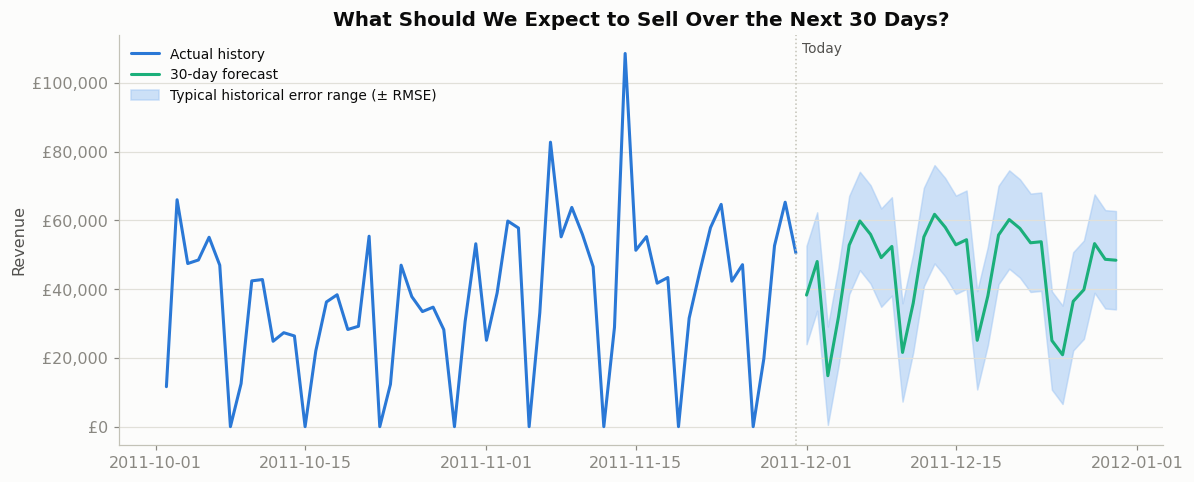

In [17]:
recent_history = hist.tail(60)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(recent_history.index, recent_history.values, color=SERIES_1, linewidth=2, label="Actual history")
ax.plot(forecast_df.index, forecast_df["Forecast"], color=SERIES_2, linewidth=2, label="30-day forecast")
ax.fill_between(
    forecast_df.index,
    (forecast_df["Forecast"] - holdout_rmse).clip(lower=0),
    forecast_df["Forecast"] + holdout_rmse,
    color=SERIES_2_BAND,
    alpha=0.5,
    label="Typical historical error range (± RMSE)",
)
ax.axvline(hist.index.max(), color=BASELINE, linewidth=1, linestyle=":")
ax.annotate("Today", xy=(hist.index.max(), ax.get_ylim()[1]), xytext=(4, -12),
            textcoords="offset points", fontsize=9, color="#52514e")
ax.set_title("What Should We Expect to Sell Over the Next 30 Days?")
ax.set_ylabel("Revenue")
currency_axis(ax)
ax.legend(frameon=False, loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig("../outputs/figures/06_future_forecast.png")
plt.show()


### Chart 7 — Product and market mix (descriptive)

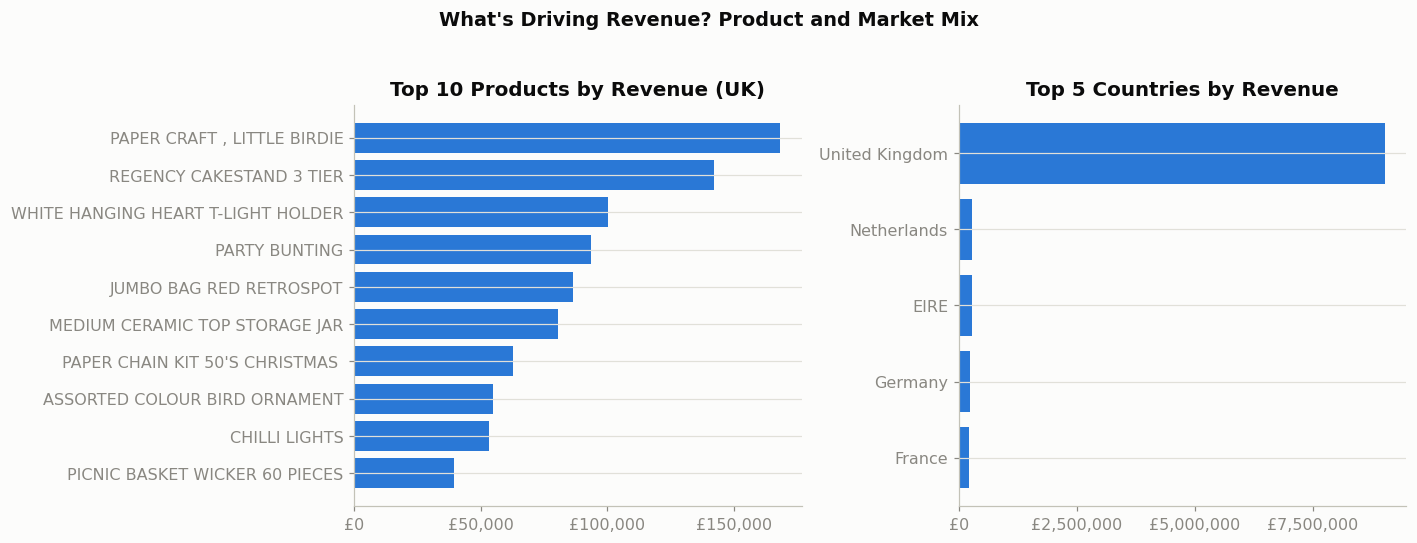

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

import matplotlib.ticker as mticker

axes[0].barh(top_products_uk.index[::-1], top_products_uk.values[::-1], color=SERIES_1)
axes[0].set_title("Top 10 Products by Revenue (UK)")
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
currency_axis(axes[0], axis="x")

axes[1].barh(top_countries.index[::-1], top_countries.values[::-1], color=SERIES_1)
axes[1].set_title("Top 5 Countries by Revenue")
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(nbins=4))
currency_axis(axes[1], axis="x")

fig.suptitle("What's Driving Revenue? Product and Market Mix", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("../outputs/figures/07_top_products_countries.png", bbox_inches="tight")
plt.show()


## 10. What This Means For Your Business

In [19]:
from IPython.display import Markdown, display

forecast_avg = forecast_df["Forecast"].mean()
forecast_total = forecast_df["Forecast"].sum()
weekly_forecast_avg = forecast_avg * 7
pct_vs_recent = (forecast_avg / recent_avg_revenue - 1) * 100

best_dow_idx = dow_avg.idxmax()
best_dow_name = dow_labels[best_dow_idx]
selling_days_avg = dow_avg[dow_avg > 0].mean()
best_dow_pct = (dow_avg[best_dow_idx] / selling_days_avg - 1) * 100

peak_month_name = monthly.idxmax().strftime("%B %Y")
peak_month_pct = (monthly.max() / monthly.mean() - 1) * 100

top_product_name = top_products_uk.index[0].title()
top_product_revenue = top_products_uk.iloc[0]

narrative = f'''
**What the forecast means.** Based on the last year of sales, we expect average daily revenue of
**£{forecast_avg:,.0f}** over the next {FORECAST_HORIZON} days ({forecast_df.index.min().strftime("%d %b")}
to {forecast_df.index.max().strftime("%d %b %Y")}), for a projected **£{forecast_total:,.0f}** in total
revenue over the period. That is about {pct_vs_recent:+.1f}% versus the most recent comparable stretch of
actuals (£{recent_avg_revenue:,.0f}/day), continuing the growth trend visible since September. The forecast
also carries forward the strong post-summer seasonal ramp seen in {peak_month_name}
(+{peak_month_pct:.0f}% vs. an average month).

**Inventory planning.** Demand is not flat across the year — the September-to-November stretch alone runs
well above the yearly average, so stock levels and supplier lead times should be planned around that ramp,
not a flat monthly average. At the product level, **{top_product_name}** was the single largest revenue
driver over the past year (£{top_product_revenue:,.0f}), alongside the rest of the top 10 shown above —
these are the items to prioritize for reorder buffers and supplier follow-up.

**Cash flow.** At the forecast pace, expect roughly **£{weekly_forecast_avg:,.0f} per week** in revenue
over the next {FORECAST_HORIZON} days. That's a useful planning number for anticipating cash inflows against
fixed costs, supplier payments, or loan obligations — but note it's a daily-revenue forecast, not a cash-timing
one (invoiced revenue and cash received don't always land in the same week).

**Staffing.** **{best_dow_name}** is consistently the strongest-selling day, running about
{best_dow_pct:.0f}% above the average selling day — and the business processes effectively no orders on
Saturdays. Staffing and fulfillment coverage should be weighted toward {best_dow_name}s and away from
Saturdays, rather than spread evenly across the week.

**A note on limitations.** Forecast accuracy degrades the further out you look — each day's prediction
partly depends on the previous day's *predicted* value, so small errors compound over the horizon. On the
56-day holdout, the {best_model_name} model was off by about £{best_mae:,.0f}/day
({best_mae_pct:.0f}% of that period's average revenue) — precise enough to guide weekly stocking and
staffing decisions, but not exact enough to predict any single day's large one-off order. We'd recommend
re-running this forecast monthly as new actuals arrive, rather than relying on one forecast for the full
{FORECAST_HORIZON}-day horizon (or longer).
'''
display(Markdown(narrative))



**What the forecast means.** Based on the last year of sales, we expect average daily revenue of
**£45,335** over the next 30 days (01 Dec
to 30 Dec 2011), for a projected **£1,360,049** in total
revenue over the period. That is about +21.4% versus the most recent comparable stretch of
actuals (£37,334/day), continuing the growth trend visible since September. The forecast
also carries forward the strong post-summer seasonal ramp seen in November 2011
(+89% vs. an average month).

**Inventory planning.** Demand is not flat across the year — the September-to-November stretch alone runs
well above the yearly average, so stock levels and supplier lead times should be planned around that ramp,
not a flat monthly average. At the product level, **Paper Craft , Little Birdie** was the single largest revenue
driver over the past year (£168,470), alongside the rest of the top 10 shown above —
these are the items to prioritize for reorder buffers and supplier follow-up.

**Cash flow.** At the forecast pace, expect roughly **£317,345 per week** in revenue
over the next 30 days. That's a useful planning number for anticipating cash inflows against
fixed costs, supplier payments, or loan obligations — but note it's a daily-revenue forecast, not a cash-timing
one (invoiced revenue and cash received don't always land in the same week).

**Staffing.** **Tuesday** is consistently the strongest-selling day, running about
31% above the average selling day — and the business processes effectively no orders on
Saturdays. Staffing and fulfillment coverage should be weighted toward Tuesdays and away from
Saturdays, rather than spread evenly across the week.

**A note on limitations.** Forecast accuracy degrades the further out you look — each day's prediction
partly depends on the previous day's *predicted* value, so small errors compound over the horizon. On the
56-day holdout, the Linear Regression model was off by about £10,480/day
(28% of that period's average revenue) — precise enough to guide weekly stocking and
staffing decisions, but not exact enough to predict any single day's large one-off order. We'd recommend
re-running this forecast monthly as new actuals arrive, rather than relying on one forecast for the full
30-day horizon (or longer).
